In [1]:
# import library 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# load data 
data = pd.read_excel(r"C:\Users\Lenovo\Desktop\mixed\New folder\Ecommerce Sales Analysis.xlsx")
data.head(2)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


# Removing Outliers 

In [ ]:
'outliers' are the unusual data  the are not ERRORS 

<Axes: ylabel='Sales'>

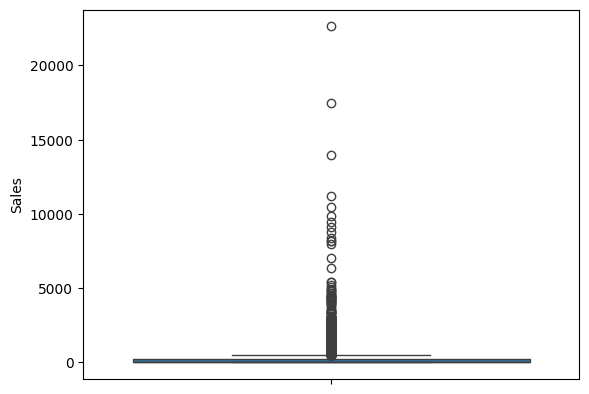

In [5]:
sns.boxplot(y='Sales', data=data)

In [ ]:
# Find and Replace 
# IQR Method 
# Zscore Method
# Mean  and Std Method 

# Remove Outliers in Sales Column 

<Axes: title={'center': 'KDE  Plot of Sales'}, xlabel='Sales', ylabel='Density'>

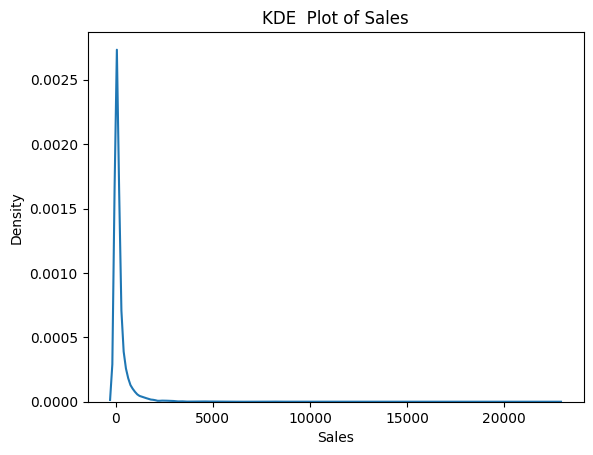

In [6]:
# Plot Sales in KDE  plot
plt.title("KDE  Plot of Sales")
sns.kdeplot(x='Sales', data=data)

In [ ]:
#  Fromm IQR 
# Q1 (first Quartile) 
# Q3 (third quartile) 
# iqr (interquartile Range) 
#Lower  Limit
# Upper Limt 

In [7]:
q1 = data['Sales'].quantile(0.25)
print(f"Q1 of Sales:{q1}")

Q1 of Sales:17.28


In [8]:
q3 = data['Sales'].quantile(0.75)
print(f"Q3 of Sales:{q3}")

Q3 of Sales:209.94


In [9]:
# IQR , inter quantile range 
iqr = q3  - q1 
print(f"IQR of Sales is :{iqr}")

IQR of Sales is :192.66


In [10]:
# Lower Limit q1 -1.5 * iqr 
lower_limit= q1 - 1.5*iqr 
print(f"Lower Limit :{lower_limit}")

Lower Limit :-271.71000000000004


In [11]:
# Upper Limit q3 + 1.5*iqr
upper_limit = q3 + 1.5 * iqr 
print(f"Upper Limit :{upper_limit}")

Upper Limit :498.93


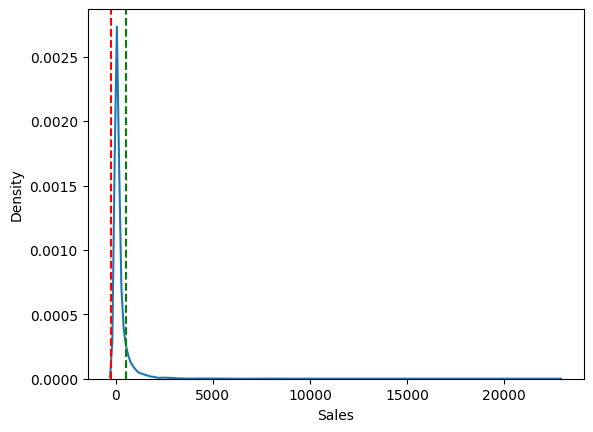

In [15]:
sns.kdeplot(x='Sales', data=data)
plt.axvline(lower_limit, linestyle='--' , color='red', label ='Lower Limit' )
plt.axvline(upper_limit, linestyle='--', color='green', label='Upper Limit')
plt.show()

In [19]:
# Remove Ouliters 
con1 = data['Sales']>=lower_limit
con2=data['Sales']<=upper_limit

In [20]:
data[con1 & con2]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
5,6,CA-2011-115812,2011,2011-06-09,2011-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2011-115812,2011,2011-06-09,2011-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200


In [22]:
df_iqr = data[con1 & con2]

Text(0.5, 1.0, 'Sales After Removing Outliers')

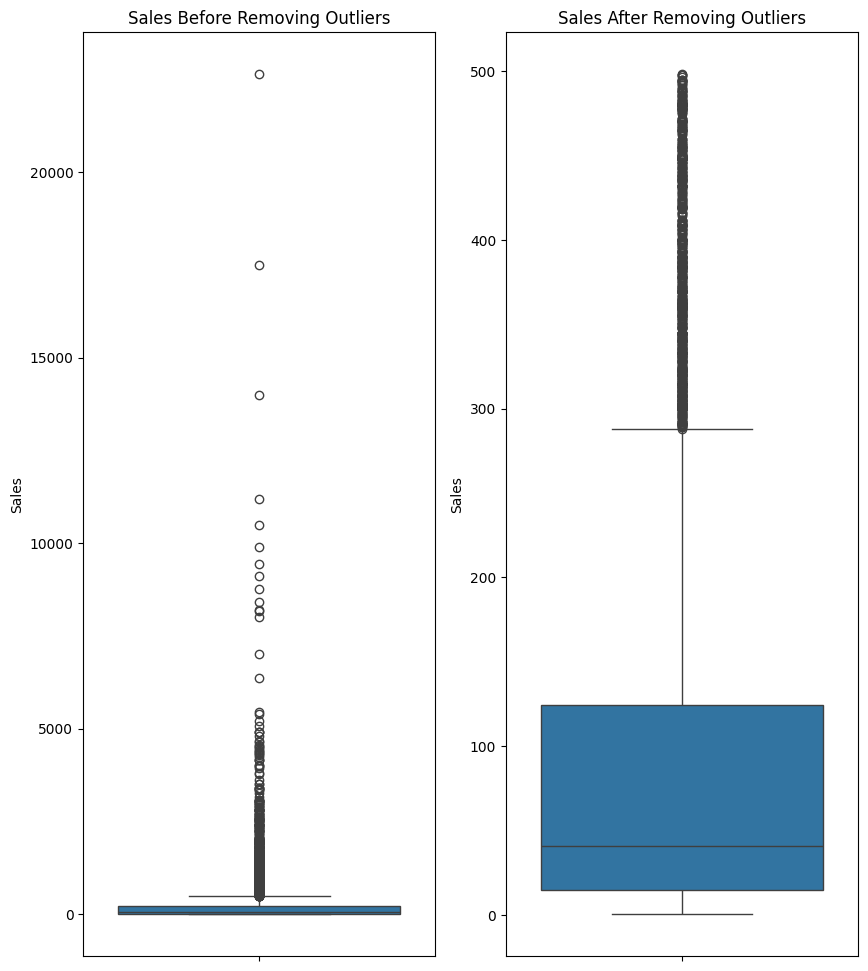

In [28]:
# Plot the Sales 
fig,axes=plt.subplots(1,2,figsize=(10,12))
sns.boxplot(y='Sales',data=data , ax=axes[0])
axes[0].set_title("Sales Before Removing Outliers")
sns.boxplot(y='Sales',data=df_iqr , ax=axes[1])
axes[1].set_title("Sales After Removing Outliers")

# Zscore Methods 

In [29]:
from scipy import stats

In [31]:
data['zscore'] = stats.zscore(data['Sales'])


In [32]:
data

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,-0.345368
3,4,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,-0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,-0.328314
9990,9991,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,-0.221269
9991,9992,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,-0.321331


In [33]:
data['zscore']  = abs(data['zscore'])

In [35]:
data[data['zscore']<=3]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.345368
3,4,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.328314
9990,9991,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.221269
9991,9992,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.321331


In [36]:
df_zscore= data[data['zscore']<=3]

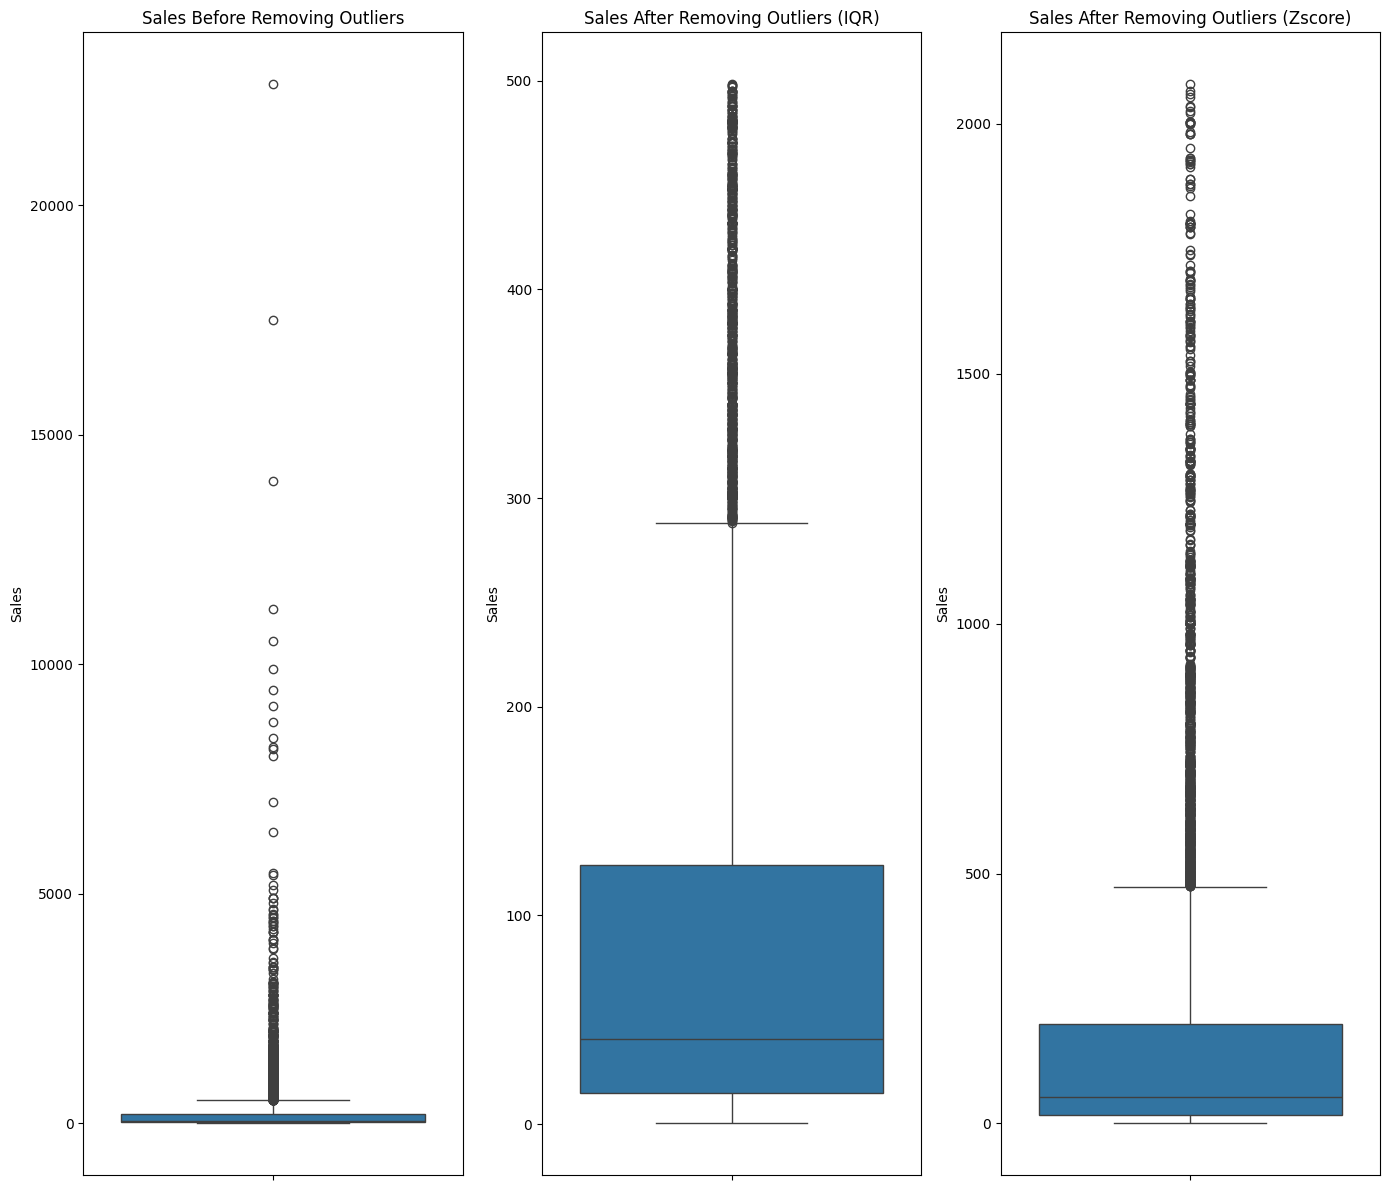

In [39]:
# Plot the Sales 
fig,axes=plt.subplots(1,3,figsize=(14,12))
sns.boxplot(y='Sales',data=data , ax=axes[0])
axes[0].set_title("Sales Before Removing Outliers")
sns.boxplot(y='Sales',data=df_iqr , ax=axes[1])
axes[1].set_title("Sales After Removing Outliers (IQR)")
sns.boxplot(y='Sales',data=df_zscore , ax=axes[2])
axes[2].set_title("Sales After Removing Outliers (Zscore)")
plt.tight_layout()

In [40]:
# STd and Mean 
sd =data['Sales'].std() 
mv = data['Sales'].mean()

In [41]:
lower_bound = mv - 3 * sd
upper_bound = mv + 3 * sd

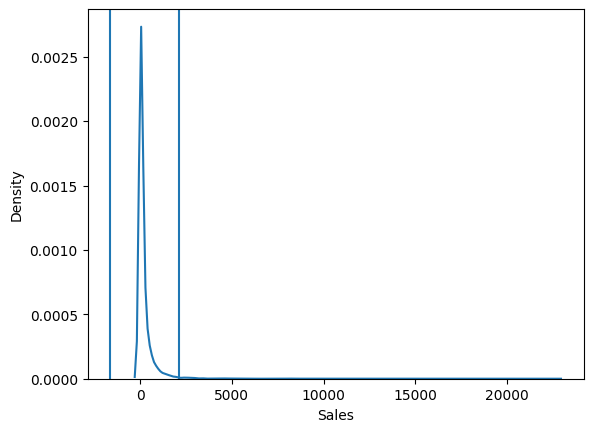

In [42]:
sns.kdeplot(x='Sales', data=data)
plt.axvline(lower_bound)
plt.axvline(upper_bound)

In [43]:
c1  = data['Sales']<=upper_bound
c2 = data['Sales']>=lower_bound

In [44]:
data[c1 & c2]

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,zscore
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.051510
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.805633
2,3,CA-2013-138688,2013,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.345368
3,4,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1.167688
4,5,US-2012-108966,2012,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.332935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.328314
9990,9991,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.221269
9991,9992,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.046080
9992,9993,CA-2014-121258,2014,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.321331


In [45]:
df_std_mean = data[c1 & c2]

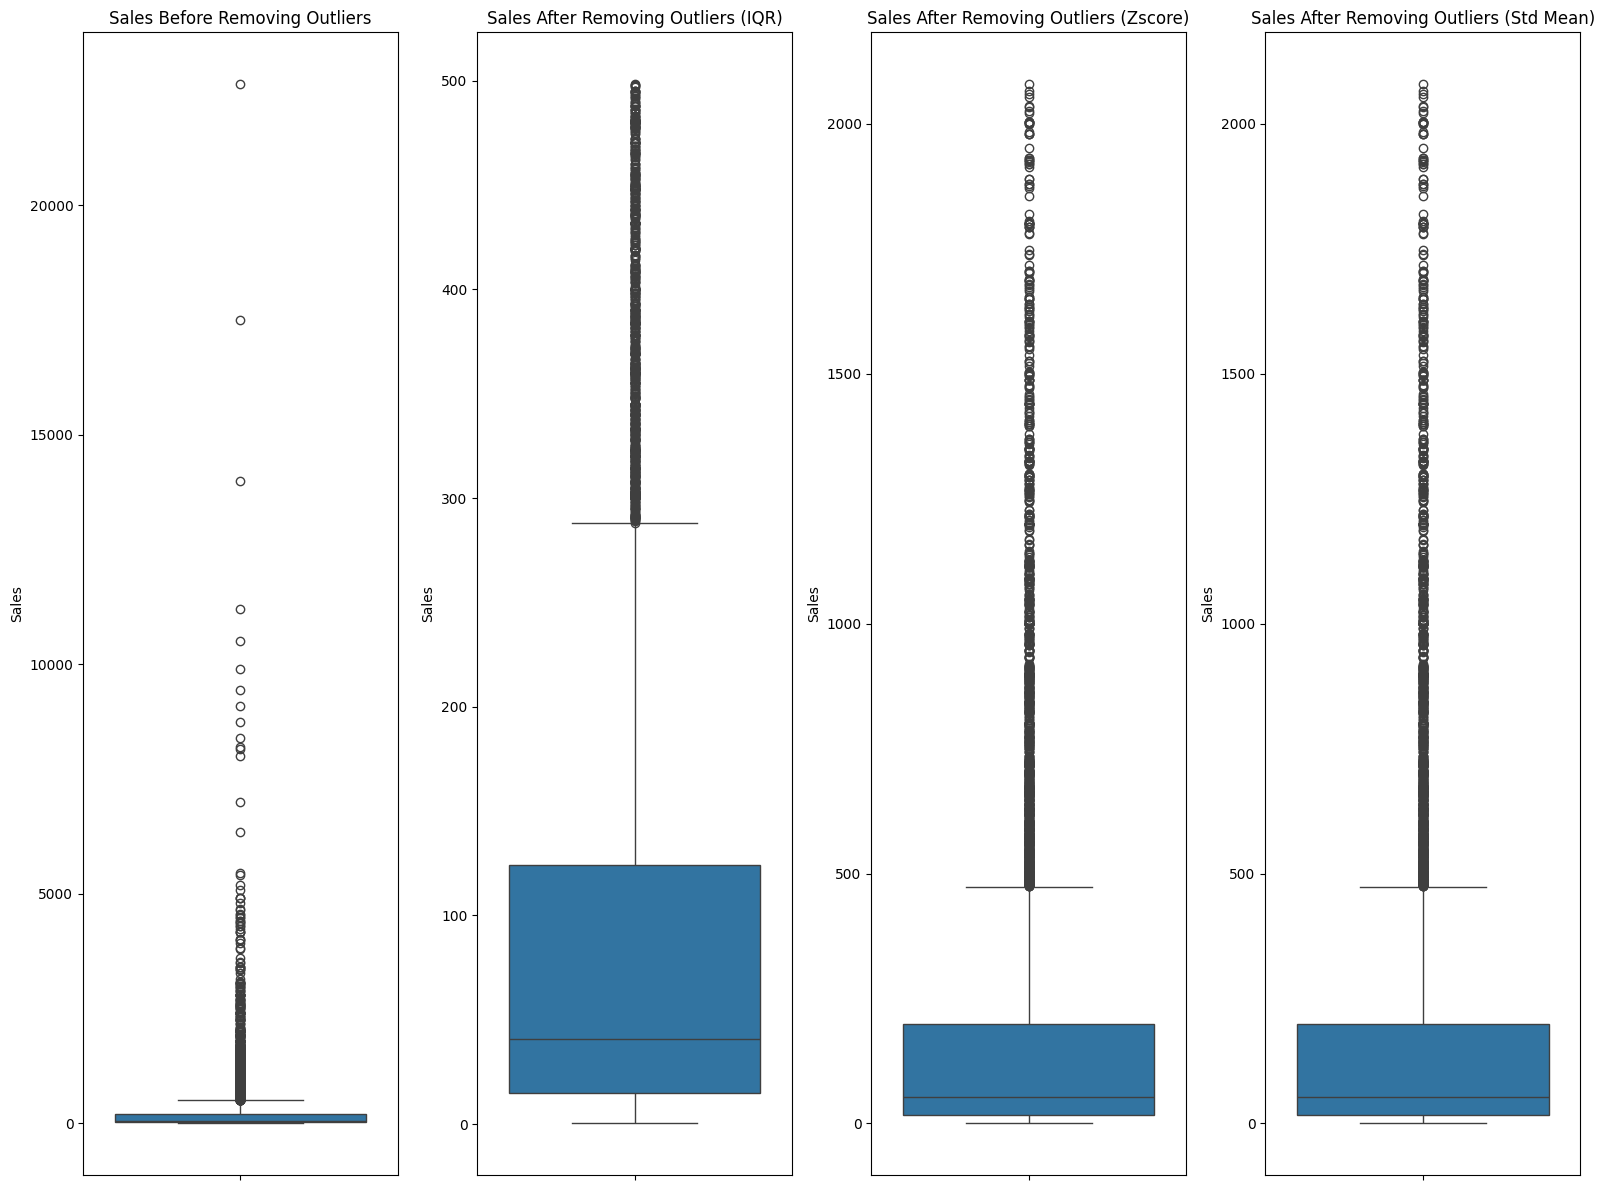

In [47]:
# Plot the Sales 
fig,axes=plt.subplots(1,4,figsize=(16,12))
sns.boxplot(y='Sales',data=data , ax=axes[0])
axes[0].set_title("Sales Before Removing Outliers")
sns.boxplot(y='Sales',data=df_iqr , ax=axes[1])
axes[1].set_title("Sales After Removing Outliers (IQR)")
sns.boxplot(y='Sales',data=df_zscore , ax=axes[2])
axes[2].set_title("Sales After Removing Outliers (Zscore)")
sns.boxplot(y='Sales',data=df_std_mean , ax=axes[3])
axes[3].set_title("Sales After Removing Outliers (Std Mean)")
plt.tight_layout()

In [48]:
# Get Skew Value 
skew_all = data['Sales'].skew() 
skew_iqr = df_iqr['Sales'].skew()
skew_zscore= df_zscore['Sales'].skew()
skew_std_mean = df_std_mean['Sales'].skew()

In [49]:
print(f"Skew of All Data:{skew_all}")
print(f"Skew of Data Removed with IQR: {skew_iqr}")
print(f"Skew of Data Removed with  Zscore :{skew_zscore}")
print(f"Skew of Data Remove with Std Mean: {skew_std_mean}")

Skew of All Data:12.97275234181623
Skew of Data Removed with IQR: 1.6850350102197387
Skew of Data Removed with  Zscore :2.9658834264117755
Skew of Data Remove with Std Mean: 2.9658834264117755


In [ ]:
# Among all the given  skew Value Skew Removed with iqr is less so , df_iqr will be considerd as data without outliers 


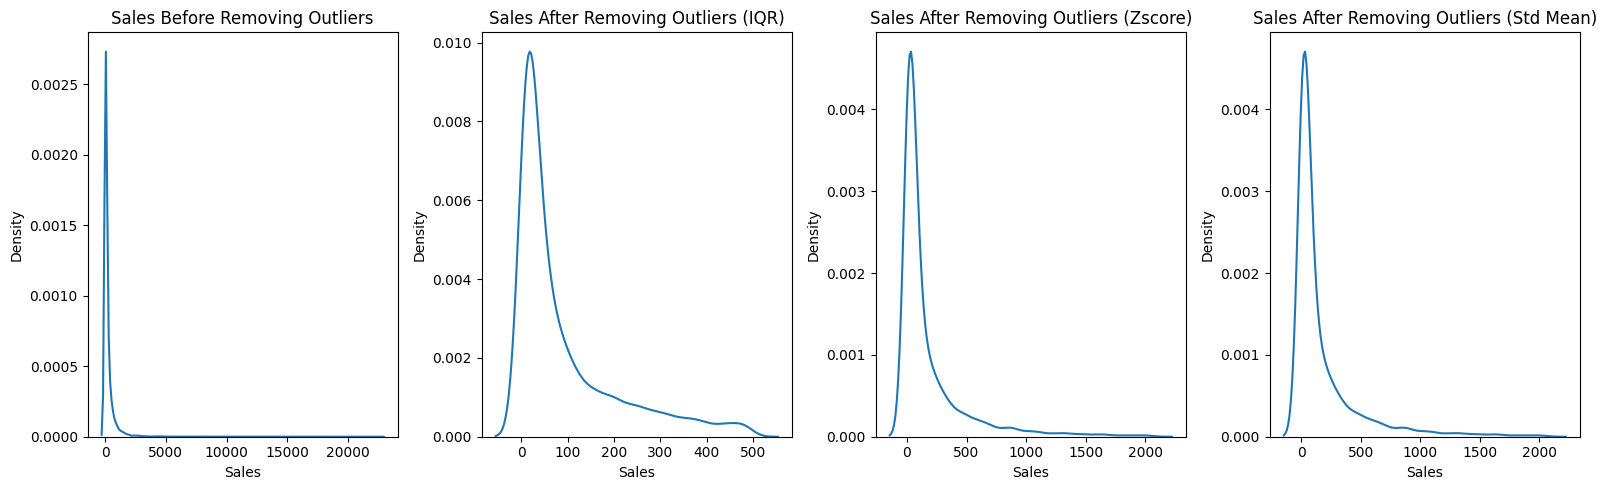

In [51]:
# Visual Inspection with KDE Plot 
# Plot the Sales 
fig,axes=plt.subplots(1,4,figsize=(16,5))
sns.kdeplot(x='Sales',data=data , ax=axes[0])
axes[0].set_title("Sales Before Removing Outliers")
sns.kdeplot(x='Sales',data=df_iqr , ax=axes[1])
axes[1].set_title("Sales After Removing Outliers (IQR)")
sns.kdeplot(x='Sales',data=df_zscore , ax=axes[2])
axes[2].set_title("Sales After Removing Outliers (Zscore)")
sns.kdeplot(x='Sales',data=df_std_mean , ax=axes[3])
axes[3].set_title("Sales After Removing Outliers (Std Mean)")
plt.tight_layout()

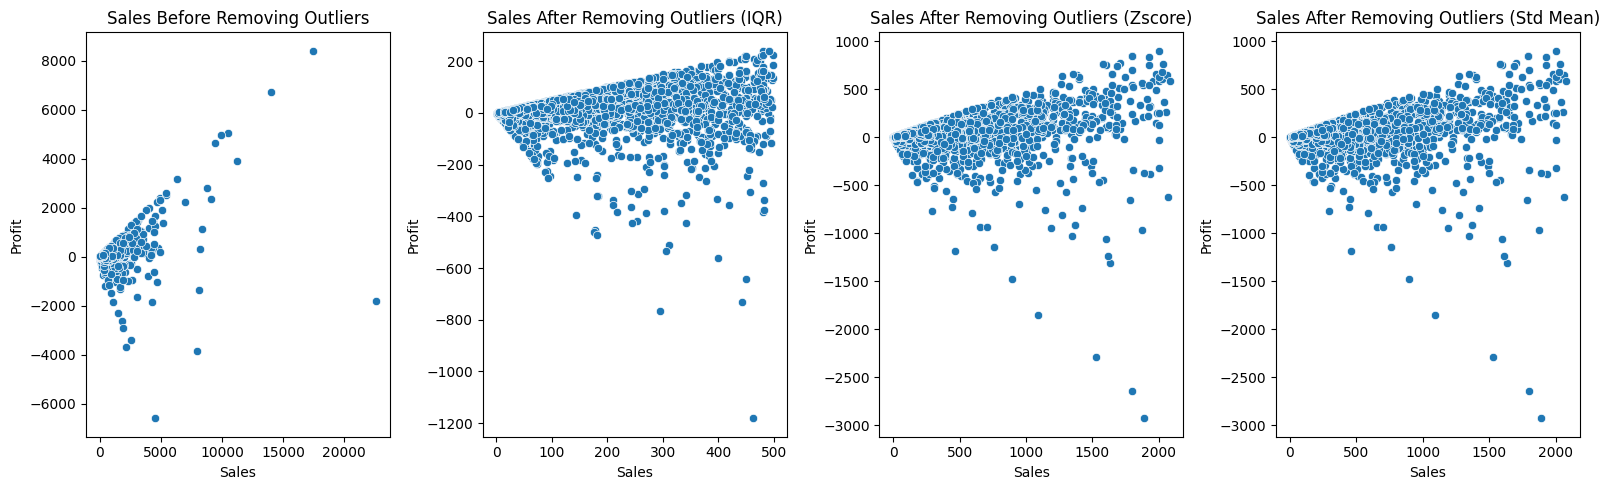

In [52]:
# Scatter Plot 
# Plot the Sales 
fig,axes=plt.subplots(1,4,figsize=(16,5))
sns.scatterplot(x='Sales',y='Profit', data=data , ax=axes[0])
axes[0].set_title("Sales Before Removing Outliers")
sns.scatterplot(x='Sales',y='Profit', data=df_iqr , ax=axes[1])
axes[1].set_title("Sales After Removing Outliers (IQR)")
sns.scatterplot(x='Sales',y='Profit',data=df_zscore , ax=axes[2])
axes[2].set_title("Sales After Removing Outliers (Zscore)")
sns.scatterplot(x='Sales',y='Profit', data=df_std_mean , ax=axes[3])
axes[3].set_title("Sales After Removing Outliers (Std Mean)")
plt.tight_layout()

In [53]:
data['Sales'].agg(['min','max', 'mean'])

min         0.444000
max     22638.480000
mean      229.858001
Name: Sales, dtype: float64

In [76]:
# EDA (Exploratory Data Analysis) 

In [ ]:
# Business Problem (Report) 
# Question Answer (jupyer Notebook) 

In [ ]:
# MySQL 